# **NUCLEI INSTANCE SEGMENTATION USING U-NET**

**PROBELM STATEMENT**\
Develop a system to accurately segment and detect cell nuclei in microscopy images, reducing the need for time-consuming manual annotation.

**OBJECTIVE**\
Build a U-Net-based deep learning model that segments nuclei, detects individual cell regions, and extracts morphological features for biomedical image analysis.

**PROPOSED SOLUTION**\
Train a lightweight U-Net on the given dataset to generate nuclei segmentation masks, followed by connected-component analysis for instance detection and feature extraction.

**METHODOLOGY**\
Preprocess microscopy images, merge instance masks into binary segmentation masks, train a U-Net model using Dice and Binary Cross-Entropy loss, and post-process predictions to identify individual nuclei and extract features.

**Model Architecture**\
A U-Net encoder–decoder network with skip connections is used to learn both global context and fine-grained spatial information for accurate pixel-level nuclei segmentation.\
**Evaluation Metrics and Method**\
Model performance is evaluated using Dice Score, Intersection over Union (IoU), and visual comparison of predicted masks against ground-truth annotations.

**Tech/Tools Used**\
Python, PyTorch, OpenCV, scikit-image, NumPy, Pandas, Matplotlib

In [18]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from skimage.measure import label, regionprops

### **CONFIG**


In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMAGE_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 10
LR = 1e-4 # fine-tuning

TRAIN_DATA_DIR = "nuclei_segmentation_unet/data/train_data"
TEST_DATA_DIR = "nuclei_segmentation_unet/data/test_data"

## **DATASET LOADER**

Dataset strucure
```
train_data/
    ├── <image_id>/
    │     ├── images/
    │     │     └── image.png
    │     ├── masks/
    │           ├── mask1.png
    │           ├── mask2.png
    test_data/
    ├── <image_id>/
    │     ├── images/
```

Since the data have multiple masks, use instance segmentation ie. Each nucleus = separate object.

In [4]:
class NucleiDataset(Dataset):

  def __init__(self, root_dir):

    """
    Args:
      root_dir (string): Directory with all the images and masks.
    """

    self.root_dir = root_dir
    self.image_ids = os.listdir(root_dir)

  def __len__(self):
    return len(self.image_ids)

  def __getitem__(self, index):

    image_id = self.image_ids[index]
    path = os.path.join(self.root_dir, image_id)

    image_path = os.path.join(path, "images", image_id + ".png")


    # Read a single image in greyscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    # scale down pixel value from 0->255 to 0->1
    image = image / 255.0

    # Create a blank image
    mask = np.zeros((IMAGE_SIZE, IMAGE_SIZE))

    mask_dir = os.path.join(path, "masks")
    for mask_file in os.listdir(mask_dir):
      mask_path = os.path.join(mask_dir, mask_file)
      mask_image = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
      mask_image = cv2.resize(mask_image, (IMAGE_SIZE, IMAGE_SIZE))
      mask = np.maximum(mask, mask_image / 255.0)

    # Add a new dimension at the front(0)
    image = np.expand_dims(image, axis=0)
    mask = np.expand_dims(mask, axis=0)

    return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [7]:
dataset = NucleiDataset(TRAIN_DATA_DIR)

train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

## **VISUALIZE THE SAMPLE**

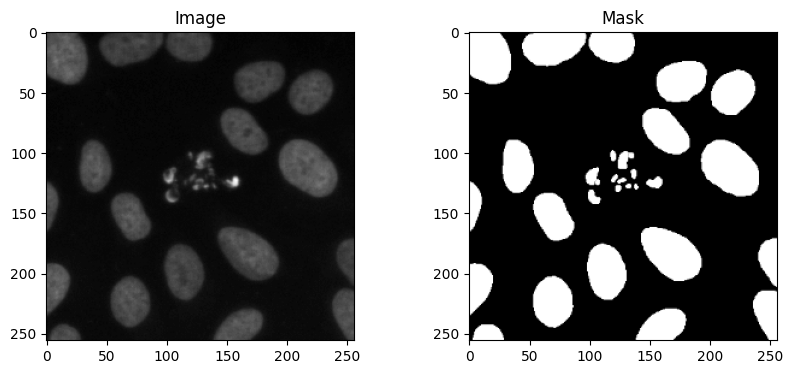

In [8]:
img, mask = dataset[410]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img[0], cmap="gray")

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask[0], cmap="gray")

plt.show()

## **IMAGE SEGMENTATION USING U-NET MODEL IMPLEMENT IN PYTORCH**

It takes image as an input and output a mask(pixel-wise prediction) ie. predicting each pixel is object/background.

In [9]:
class DoubleConv(nn.Module):

  """
  Feature extraction + Refinement block:
  Applies Conv → ReLU → Conv → ReLU
  """

  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )

  def forward(self, x):
    return self.conv(x)


class UNet(nn.Module):

  def __init__(self):
    super().__init__()

    # --ENCODER--

    # Extract 32 feature maps
    self.down1 = DoubleConv(1, 32)
    # Reduce image size by half (pooling)
    self.pool1 = nn.MaxPool2d(2)

    self.down2 = DoubleConv(32, 64)
    self.pool2 = nn.MaxPool2d(2)

    self.bottleneck = DoubleConv(64, 128)

    # --DECODER--

    # Upsample
    self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
    # Refine and merge feature
    self.dec2 = DoubleConv(128, 64)

    self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
    self.dec1 = DoubleConv(64, 32)

    # 1x1 convolution
    self.out = nn.Conv2d(32, 1, 1)

  def forward(self, x):

    d1 = self.down1(x)
    d2 = self.down2(self.pool1(d1))

    b = self.bottleneck(self.pool2(d2))

    u2 = self.up2(b)
    #Skip connection
    u2 = torch.cat([u2, d2], dim=1)
    u2 = self.dec2(u2)

    u1 = self.up1(u2)
    u1 = torch.cat([u1, d1], dim=1)
    u1 = self.dec1(u1)

    # sigmoid to convert the output into probabilities
    return torch.sigmoid(self.out(u1))


## **LOSS FUNCTION**

```
BCE	      pixel accuracy
Dice      Shape / overlap quality
```

In [10]:
bce = nn.BCELoss()

def dice_loss(pred, target):
  smooth = 1e-6
  intersection = (pred * target).sum()

  return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

**MODEL + OPTIMIZER**

In [11]:
model = UNet().to(DEVICE)


In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

## **TRAIN LOOP**

In [13]:
for epoch in range(EPOCHS):
  model.train()
  total_loss = 0

  for image, mask in tqdm(train_loader):
    image, mask = image.to(DEVICE), mask.to(DEVICE)

    # Forward pass
    pred = model(image)

    loss = bce(pred, mask) + dice_loss(pred, mask)

    optimizer.zero_grad()
    # Backpropagation
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  print(f"Epoch: {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader)}")


100%|██████████| 84/84 [00:44<00:00,  1.89it/s]


Epoch: 1/10, Loss: 1.3559306192965734


100%|██████████| 84/84 [00:45<00:00,  1.87it/s]


Epoch: 2/10, Loss: 1.0851408044497173


100%|██████████| 84/84 [00:42<00:00,  1.97it/s]


...

Epoch: 8/10, Loss: 0.3376745625975586


100%|██████████| 84/84 [00:43<00:00,  1.92it/s]


Epoch: 9/10, Loss: 0.32315282488153096


100%|██████████| 84/84 [00:43<00:00,  1.94it/s]

Epoch: 10/10, Loss: 0.31035351895150687


## **PREDICTION VISUALIZATION**

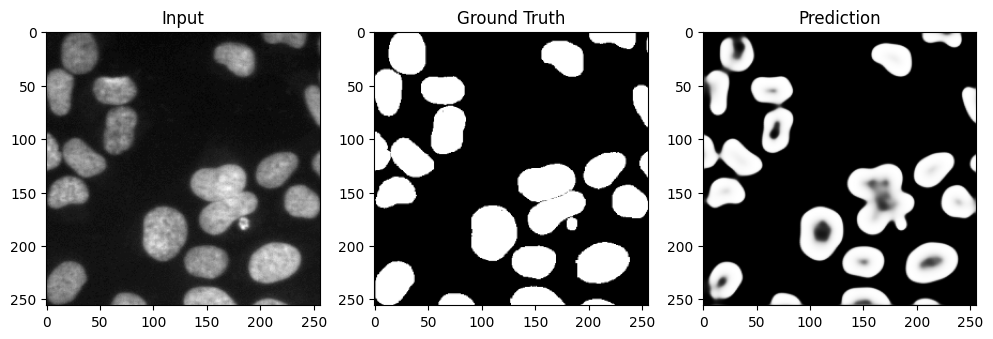

In [72]:
model.eval()

img, mask = dataset[0]
img_in = img.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred = model(img_in).cpu().numpy()[0,0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(img[0], cmap="gray")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask[0], cmap="gray")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred, cmap="gray")

plt.show()

## **INSTANCE SEGMENTATION**

Perform connected component labelling ie. find every connected group of (1)s and assigns each group a unique integer

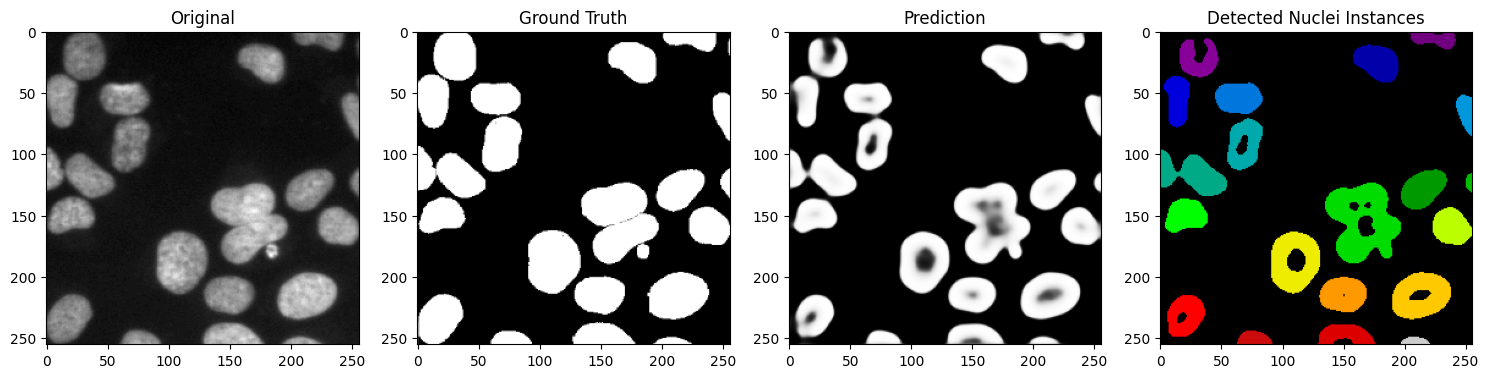

In [73]:
binary = (pred > 0.5).astype(np.uint8)

plt.figure(figsize=(15,4))

# 1. Original
plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(img_np, cmap="gray")

# 2. Ground Truth
plt.subplot(1,4,2)
plt.title("Ground Truth")
plt.imshow(mask_np, cmap="gray")

# 3. Prediction
plt.subplot(1,4,3)
plt.title("Prediction")
plt.imshow(pred, cmap="gray")

# 4. Detected Nuclei
plt.subplot(1,4,4)
plt.title("Detected Nuclei Instances")
plt.imshow(instances, cmap="nipy_spectral")

plt.tight_layout()
plt.show()

## **FEATURE EXTRACTION**

In [51]:
features =[]

for image_id in dataset.image_ids:

  for region in regionprops(instances):
    area = region.area
    centroid = region.centroid
    perimeter = region.perimeter
    eccentricity = region.eccentricity
    extent = region.extent
    solidity = region.solidity
    circularity = 4 * np.pi * area / (perimeter ** 2)

    features.append([image_id, area, *centroid, perimeter, eccentricity, extent, solidity, circularity])

df = pd.DataFrame(features, columns=["image_id", "area", "centroid-0", "centroid-1", "perimeter", "eccentricity", "extent", "solidity", "circularity"])
df.to_csv("features.csv")
df.head()

,image_id,area,centroid-0,centroid-1,perimeter,eccentricity,extent,solidity,circularity
0,b4de1e3eec159d8af1bd5447696f8996c31709edaf33e2...,393.0,5.821883,223.931298,95.698485,0.948923,0.708108,0.848812,0.539253
1,b4de1e3eec159d8af1bd5447696f8996c31709edaf33e2...,667.0,22.440780,30.758621,143.639610,0.469408,0.651367,0.777389,0.406244
2,b4de1e3eec159d8af1bd5447696f8996c31709edaf33e2...,843.0,25.142349,177.403321,110.911688,0.744013,0.734961,0.961231,0.861158
3,b4de1e3eec159d8af1bd5447696f8996c31709edaf33e2...,656.0,55.850610,13.862805,107.355339,0.902144,0.743764,0.914923,0.715264
4,b4de1e3eec159d8af1bd5447696f8996c31709edaf33e2...,810.0,54.330864,63.832099,107.840620,0.754775,0.798817,0.961995,0.875246


## **EVALUATION**

In [52]:
def dice_score(pred, target):
  pred = (pred > 0.5).float()
  smooth = 1e-6
  intersection = (pred * target).sum()
  return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def iou_score(pred, target):
  pred = (pred > 0.5).float()
  intersection = (pred * target).sum()
  union = (pred + target - pred * target).sum()
  return (intersection + 1e-6) / (union + 1e-6)


def precision_score(pred, target):
  pred = (pred > 0.5).float()
  tp = (pred * target).sum()
  fp = (pred * (1 - target)).sum()
  return tp / (tp + fp + 1e-6)


def recall_score(pred, target):
  pred = (pred > 0.5).float()
  tp = (pred * target).sum()
  fn = ((1 - pred) * target).sum()
  return tp / (tp + fn + 1e-6)

**METRICS REPORT:**

In [53]:
model.eval()

dice_list, iou_list, prec_list, rec_list = [], [], [], []

with torch.no_grad():
    for img, mask in train_loader:
        img, mask = img.to(DEVICE), mask.to(DEVICE)

        pred = model(img)

        dice_list.append(dice_score(pred, mask).item())
        iou_list.append(iou_score(pred, mask).item())
        prec_list.append(precision_score(pred, mask).item())
        rec_list.append(recall_score(pred, mask).item())

print("U-NET MODEL EVALUATION RESULTS")
print("Dice Score   :", np.mean(dice_list))
print("IoU Score    :", np.mean(iou_list))
print("Precision    :", np.mean(prec_list))
print("Recall       :", np.mean(rec_list))

U-NET MODEL EVALUATION RESULTS
Dice Score   : 0.8439357011091142
IoU Score    : 0.7326098740810439
Precision    : 0.878103901942571
Recall       : 0.8167604470536822


**SAVE THE MODEL**

In [65]:
torch.save(model.state_dict(), "unet_nuclei.pth")
print("Model saved successfully!")

Model saved successfully!
